# Lab 6 (Step 2): Our Group vs Other Group Indoor and Outdoor Data Comparison

This notebook compares indoor (`indoor.csv`) and outdoor (`rundata.csv`) measurements collected by our group to indoor (`aq_temp_inside.csv`) and outdoor (`aq_temp_outside.csv`) collected by another group.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# Load data
# -----------------------------
indoor     = pd.read_csv("indoor.csv")           # Our Group Indoor
rundata    = pd.read_csv("rundata.csv")          # Our Group Outdoor
aq_inside  = pd.read_csv("aq_temp_inside.csv")   # Other Group Indoor
aq_inside = aq_inside.iloc[1:].reset_index(drop=True)  # drop bad first pressure datapoint
aq_outside = pd.read_csv("aq_temp_outside.csv")  # Other Group Outdoor

# -----------------------------
# Column mappings
# Compare ONLY these variables (disregard all others):
#   Other Group column   <->  Our Group column
#   Time                 <->  Timestamp
#   Temperature          <->  Temp
#   Humidity             <->  Humidity
#   Pressure             <->  Pressure
#   2.5                  <->  PM25_Env
# -----------------------------
PAIR_MAP = {
    "Temperature": "Temp",
    "Humidity": "Humidity",
    "Pressure": "Pressure",
    "2.5": "PM25_Env",
}

T_END = 300  # seconds

def prepare_df(df, time_col, keep_cols, t_end=T_END, gap_threshold=30):
    """Keep only required columns, build a relative time axis in seconds, and trim to [0, t_end].

    Notes:
    - Some logs include an early 'stray' record far away (in time) from the main run.
      To avoid chopping off the main run when we later trim to 0..t_end, we detect a
      large time gap and, if it occurs near the beginning, we start at the first sample
      *after* that gap.
    """
    df = df.copy()

    cols = [time_col] + [c for c in keep_cols if c in df.columns]
    df = df[cols]

    # Convert time to numeric (seconds-like) and drop non-numeric rows
    t = pd.to_numeric(df[time_col], errors="coerce")
    df = df.assign(t_raw=t).dropna(subset=["t_raw"]).copy()

    # Sort by time
    df = df.sort_values("t_raw").reset_index(drop=True)

    # Choose a robust t0
    t_raw = df["t_raw"].to_numpy()
    if len(t_raw) >= 2:
        dt = np.diff(t_raw)
        # Find the first large gap
        large_gap_idx = np.where(dt > gap_threshold)[0]
        if large_gap_idx.size > 0:
            j = int(large_gap_idx[0] + 1)  # first index after the gap
            # Only apply if the gap is near the beginning (likely a stray startup record)
            if j <= max(5, int(0.1 * len(df))):
                df = df.iloc[j:].reset_index(drop=True)
                t_raw = df["t_raw"].to_numpy()

    t0 = float(t_raw[0]) if len(t_raw) else np.nan
    df["t_sec"] = df["t_raw"] - t0

    # Coerce required data columns to numeric
    for c in keep_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Trim to [0, t_end]
    df = df[(df["t_sec"] >= 0) & (df["t_sec"] <= t_end)].copy()
    return df

def drop_first_seconds_and_rezero(df, seconds, t_end=T_END):
    """Drop the first `seconds` of data (by t_sec) and re-zero time so plots run 0..t_end."""
    if seconds is None or seconds <= 0 or len(df) == 0:
        return df
    df = df[df["t_sec"] >= seconds].copy()
    df["t_sec"] = df["t_sec"] - seconds
    df = df[(df["t_sec"] >= 0) & (df["t_sec"] <= t_end)].copy()
    return df

def stats_table(x_a, x_b, label_a, label_b):
    x_a = np.asarray(x_a, dtype=float)
    x_b = np.asarray(x_b, dtype=float)
    x_a = x_a[np.isfinite(x_a)]
    x_b = x_b[np.isfinite(x_b)]

    def _stats(x):
        if len(x) == 0:
            return {"N": 0, "Mean": np.nan, "Std": np.nan, "Min": np.nan, "Max": np.nan}
        return {"N": len(x), "Mean": np.mean(x), "Std": np.std(x, ddof=1) if len(x) > 1 else 0.0,
                "Min": np.min(x), "Max": np.max(x)}

    a = _stats(x_a); b = _stats(x_b)
#     return pd.DataFrame([a, b], index=[label_a, label_b])  # removed per request


def stats_and_test(x_a, x_b):
    """Return a dict of descriptive stats + how many sigma apart the means are."""
    x_a = pd.to_numeric(pd.Series(x_a), errors="coerce").to_numpy(dtype=float)
    x_b = pd.to_numeric(pd.Series(x_b), errors="coerce").to_numpy(dtype=float)

    x_a = x_a[np.isfinite(x_a)]
    x_b = x_b[np.isfinite(x_b)]

    n_a, n_b = len(x_a), len(x_b)
    mean_a = np.mean(x_a) if n_a else np.nan
    mean_b = np.mean(x_b) if n_b else np.nan

    sigma_a = np.std(x_a, ddof=1) if n_a > 1 else np.nan
    sigma_b = np.std(x_b, ddof=1) if n_b > 1 else np.nan

    sigma_mean_a = sigma_a / np.sqrt(n_a) if n_a > 1 else np.nan
    sigma_mean_b = sigma_b / np.sqrt(n_b) if n_b > 1 else np.nan

    sigma_diff = np.sqrt(sigma_mean_a**2 + sigma_mean_b**2) if np.isfinite(sigma_mean_a) and np.isfinite(sigma_mean_b) else np.nan
    diff = abs(mean_a - mean_b) if np.isfinite(mean_a) and np.isfinite(mean_b) else np.nan
    n_sigma = (diff / sigma_diff) if np.isfinite(diff) and np.isfinite(sigma_diff) and sigma_diff != 0 else np.nan

    return {
        "n_a": n_a, "n_b": n_b,
        "mean_a": mean_a, "mean_b": mean_b,
        "sigma_a": sigma_a, "sigma_b": sigma_b,
        "sigma_mean_a": sigma_mean_a, "sigma_mean_b": sigma_mean_b,
        "diff": diff, "sigma_diff": sigma_diff,
        "n_sigma": n_sigma,
        "different_3sigma": bool(np.isfinite(n_sigma) and n_sigma > 3.0),
    }

def compare_one_variable(df_a, df_b, col_a, col_b, label_a, label_b, env_label, var_label):
    """Plot time series + histogram for one variable (Our Group vs Other Group)."""
    # Time series
    plt.figure()
    plt.plot(df_a["t_sec"], df_a[col_a], label=label_a)
    plt.plot(df_b["t_sec"], df_b[col_b], label=label_b)
    plt.xlim(0, T_END)
    plt.xlabel("Time (s)")
    plt.ylabel(var_label)
    plt.title(f"Our Group vs Other Group {env_label} {var_label} (Time Series)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    # Histogram
    plt.figure()
    plt.hist(df_a[col_a].dropna(), bins=30, alpha=0.6, label=label_a)
    plt.hist(df_b[col_b].dropna(), bins=30, alpha=0.6, label=label_b)
    plt.xlabel(var_label)
    plt.ylabel("Count")
    plt.title(f"Our Group vs Other Group {env_label} {var_label} (Histogram)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    # Summary stats table
#     display(stats_table(df_a[col_a], df_b[col_b], label_a, label_b))  # removed per request

    # Full stats + sigma separation (matches the other notebook)
    s = stats_and_test(df_a[col_a], df_b[col_b])
    print(f"--- {env_label} {var_label} ---")
    print(f"N {label_a} = {s['n_a']}, N {label_b} = {s['n_b']}")
    print(f"Mean {label_a}  = {s['mean_a']:.6g}")
    print(f"Mean {label_b} = {s['mean_b']:.6g}")
    print(f"Sigma (intrinsic) {label_a}  = {s['sigma_a']:.6g}")
    print(f"Sigma (intrinsic) {label_b} = {s['sigma_b']:.6g}")
    print(f"Sigma_mean {label_a}  = {s['sigma_mean_a']:.6g}")
    print(f"Sigma_mean {label_b} = {s['sigma_mean_b']:.6g}")
    print(f"|Δmean| = {s['diff']:.6g}")
    print(f"Combined sigma_mean (for Δ) = {s['sigma_diff']:.6g}")
    print(f"Separation (|Δmean| / σΔmean) = {s['n_sigma']:.6g} σ")
    if s["different_3sigma"]:
        print("Statistically different at > 3σ")
    else:
        print("Not statistically different at > 3σ")
# -----------------------------
# Prepare datasets
# -----------------------------
our_indoor   = prepare_df(indoor,     time_col="Timestamp", keep_cols=list(PAIR_MAP.values()))
other_indoor = prepare_df(aq_inside,  time_col="Time",      keep_cols=list(PAIR_MAP.keys()))

our_outdoor   = prepare_df(rundata,    time_col="Timestamp", keep_cols=list(PAIR_MAP.values()))
other_outdoor = prepare_df(aq_outside, time_col="Time",      keep_cols=list(PAIR_MAP.keys()))

# Mask off first 30 seconds for OUTDOOR comparison (from each dataset), then re-zero time to start at 0s
our_outdoor   = drop_first_seconds_and_rezero(our_outdoor,   30)
other_outdoor = drop_first_seconds_and_rezero(other_outdoor, 30)

LABEL_OUR_INDOOR   = "Our Group Indoor"
LABEL_OTHER_INDOOR = "Other Group Indoor"
LABEL_OUR_OUTDOOR  = "Our Group Outdoor"
LABEL_OTHER_OUTDOOR= "Other Group Outdoor"


## Indoor comparisons (Our Group Indoor vs Other Group Indoor)
Each variable comparison is in its own cell.

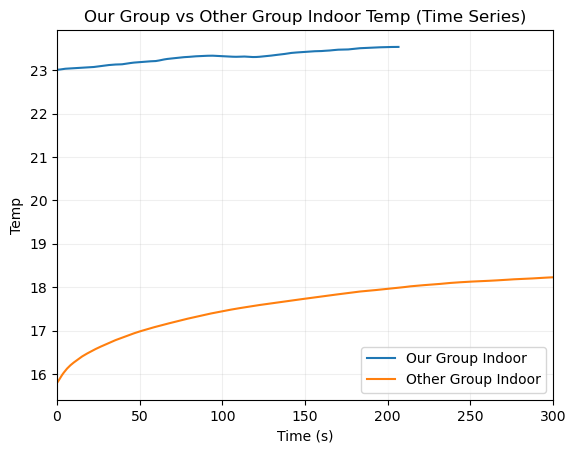

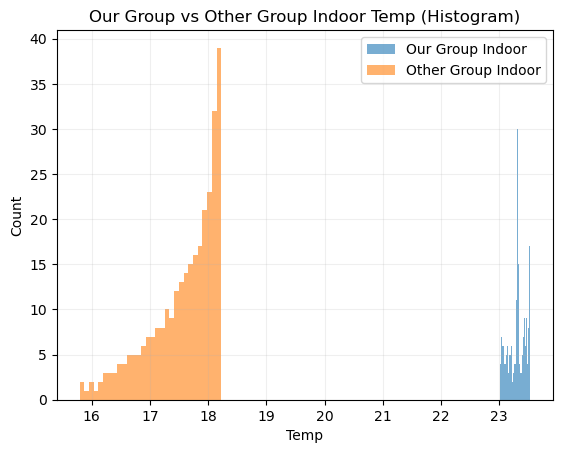

--- Indoor Temp ---
N Our Group Indoor = 205, N Other Group Indoor = 297
Mean Our Group Indoor  = 23.3049
Mean Other Group Indoor = 17.573
Sigma (intrinsic) Our Group Indoor  = 0.150796
Sigma (intrinsic) Other Group Indoor = 0.578681
Sigma_mean Our Group Indoor  = 0.010532
Sigma_mean Other Group Indoor = 0.0335785
|Δmean| = 5.73191
Combined sigma_mean (for Δ) = 0.0351915
Separation (|Δmean| / σΔmean) = 162.878 σ
Statistically different at > 3σ


In [11]:
# Indoor: Temp
compare_one_variable(
    df_a=our_indoor,
    df_b=other_indoor,
    col_a="Temp",
    col_b="Temperature",
    label_a="Our Group Indoor",
    label_b="Other Group Indoor",
    env_label="Indoor",
    var_label="Temp",
)


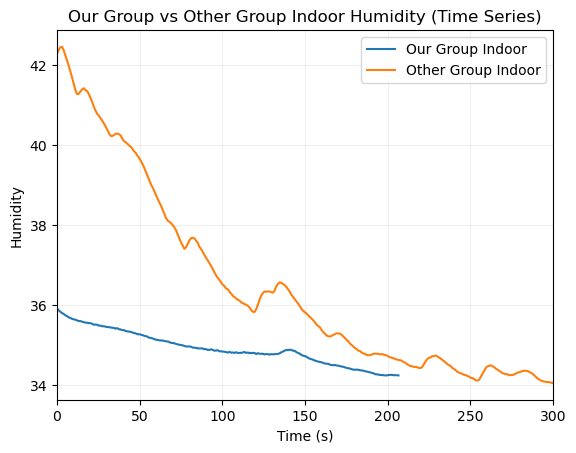

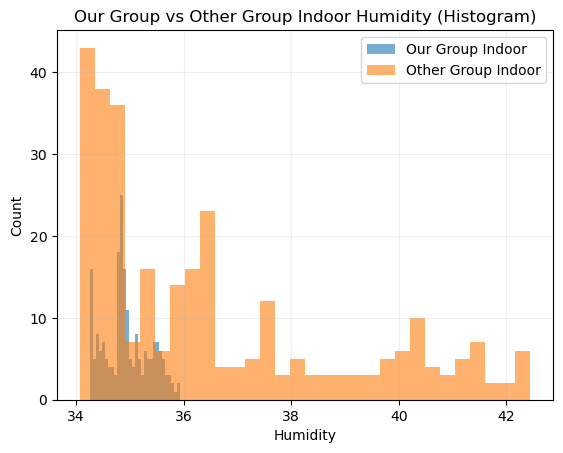

--- Indoor Humidity ---
N Our Group Indoor = 205, N Other Group Indoor = 297
Mean Our Group Indoor  = 34.9307
Mean Other Group Indoor = 36.4962
Sigma (intrinsic) Our Group Indoor  = 0.422224
Sigma (intrinsic) Other Group Indoor = 2.3799
Sigma_mean Our Group Indoor  = 0.0294894
Sigma_mean Other Group Indoor = 0.138096
|Δmean| = 1.5655
Combined sigma_mean (for Δ) = 0.141209
Separation (|Δmean| / σΔmean) = 11.0864 σ
Statistically different at > 3σ


In [12]:
# Indoor: Humidity
compare_one_variable(
    df_a=our_indoor,
    df_b=other_indoor,
    col_a="Humidity",
    col_b="Humidity",
    label_a="Our Group Indoor",
    label_b="Other Group Indoor",
    env_label="Indoor",
    var_label="Humidity",
)


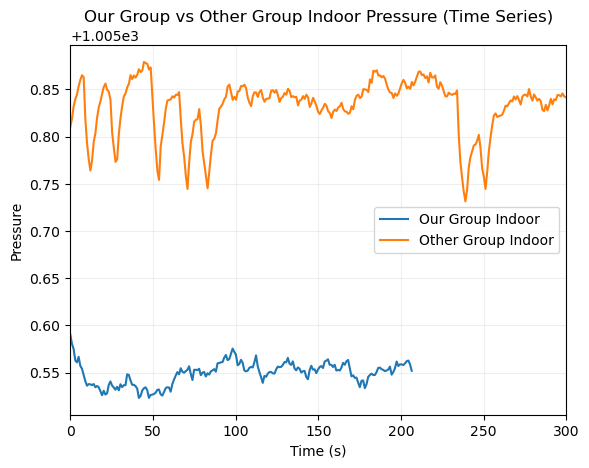

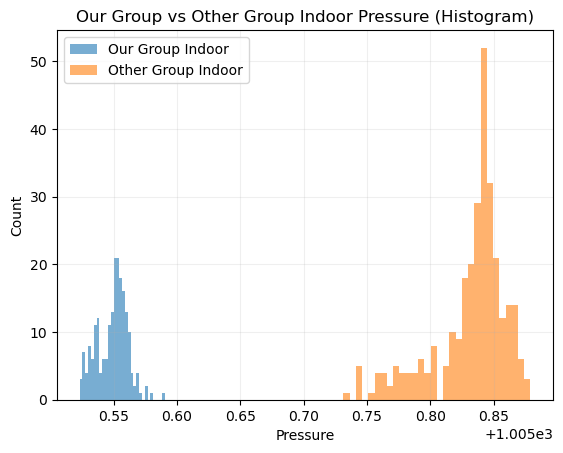

--- Indoor Pressure ---
N Our Group Indoor = 205, N Other Group Indoor = 297
Mean Our Group Indoor  = 1005.55
Mean Other Group Indoor = 1005.83
Sigma (intrinsic) Our Group Indoor  = 0.01198
Sigma (intrinsic) Other Group Indoor = 0.0291305
Sigma_mean Our Group Indoor  = 0.000836721
Sigma_mean Other Group Indoor = 0.00169032
|Δmean| = 0.282846
Combined sigma_mean (for Δ) = 0.00188608
Separation (|Δmean| / σΔmean) = 149.965 σ
Statistically different at > 3σ


In [13]:
# Indoor: Pressure
compare_one_variable(
    df_a=our_indoor,
    df_b=other_indoor,
    col_a="Pressure",
    col_b="Pressure",
    label_a="Our Group Indoor",
    label_b="Other Group Indoor",
    env_label="Indoor",
    var_label="Pressure",
)


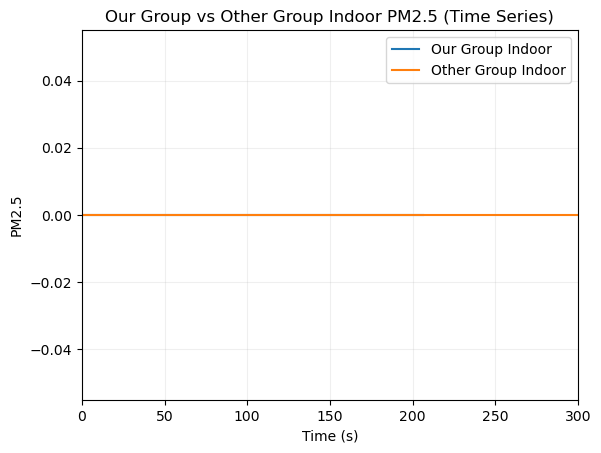

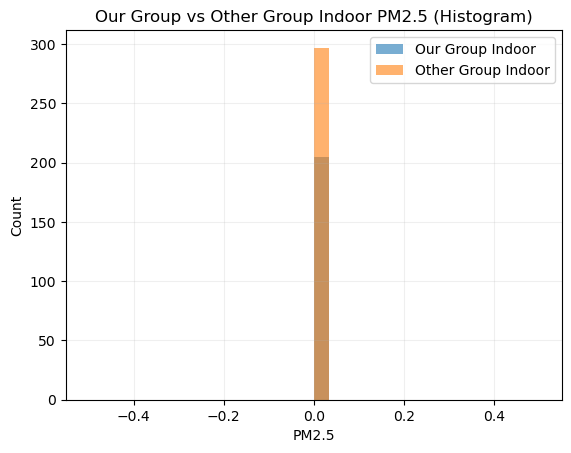

--- Indoor PM2.5 ---
N Our Group Indoor = 205, N Other Group Indoor = 297
Mean Our Group Indoor  = 0
Mean Other Group Indoor = 0
Sigma (intrinsic) Our Group Indoor  = 0
Sigma (intrinsic) Other Group Indoor = 0
Sigma_mean Our Group Indoor  = 0
Sigma_mean Other Group Indoor = 0
|Δmean| = 0
Combined sigma_mean (for Δ) = 0
Separation (|Δmean| / σΔmean) = nan σ
Not statistically different at > 3σ


In [14]:
# Indoor: PM2.5
compare_one_variable(
    df_a=our_indoor,
    df_b=other_indoor,
    col_a="PM25_Env",
    col_b="2.5",
    label_a="Our Group Indoor",
    label_b="Other Group Indoor",
    env_label="Indoor",
    var_label="PM2.5",
)


## Outdoor comparisons (Our Group Outdoor vs Other Group Outdoor)
Each variable comparison is in its own cell. (First 30 seconds removed from each dataset; time re-zeroed.)

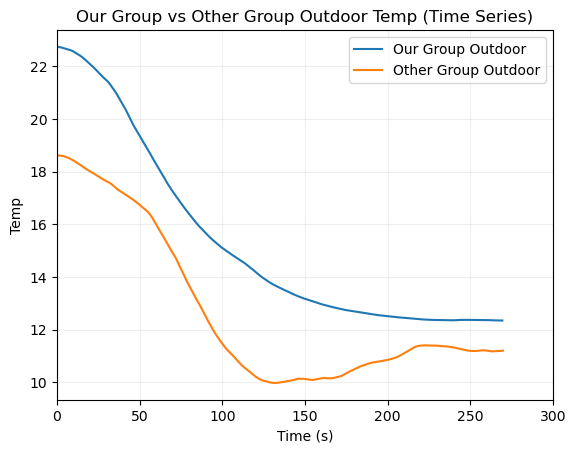

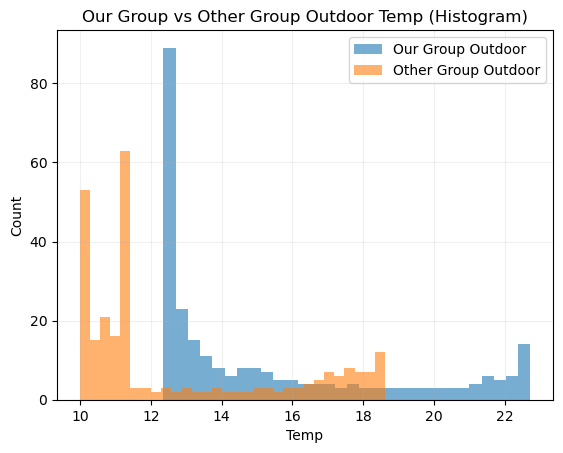

--- Outdoor Temp ---
N Our Group Outdoor = 266, N Other Group Outdoor = 267
Mean Our Group Outdoor  = 15.2955
Mean Other Group Outdoor = 12.6934
Sigma (intrinsic) Our Group Outdoor  = 3.45303
Sigma (intrinsic) Other Group Outdoor = 2.90418
Sigma_mean Our Group Outdoor  = 0.211719
Sigma_mean Other Group Outdoor = 0.177733
|Δmean| = 2.60209
Combined sigma_mean (for Δ) = 0.27643
Separation (|Δmean| / σΔmean) = 9.4132 σ
Statistically different at > 3σ


In [15]:
# Outdoor: Temp
compare_one_variable(
    df_a=our_outdoor,
    df_b=other_outdoor,
    col_a="Temp",
    col_b="Temperature",
    label_a="Our Group Outdoor",
    label_b="Other Group Outdoor",
    env_label="Outdoor",
    var_label="Temp",
)


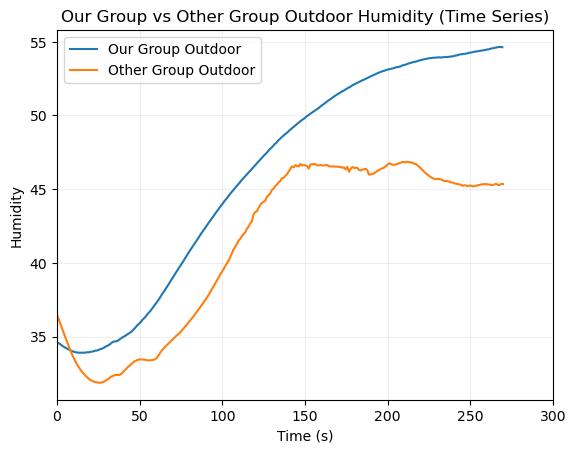

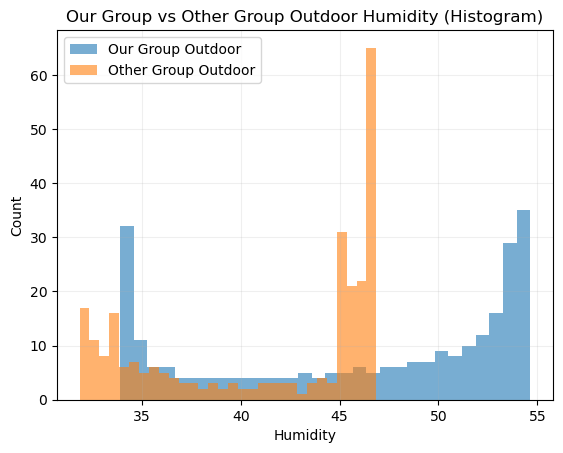

--- Outdoor Humidity ---
N Our Group Outdoor = 266, N Other Group Outdoor = 267
Mean Our Group Outdoor  = 46.0812
Mean Other Group Outdoor = 41.3147
Sigma (intrinsic) Our Group Outdoor  = 7.50026
Sigma (intrinsic) Other Group Outdoor = 5.66274
Sigma_mean Our Group Outdoor  = 0.45987
Sigma_mean Other Group Outdoor = 0.346554
|Δmean| = 4.76658
Combined sigma_mean (for Δ) = 0.57583
Separation (|Δmean| / σΔmean) = 8.27775 σ
Statistically different at > 3σ


In [16]:
# Outdoor: Humidity
compare_one_variable(
    df_a=our_outdoor,
    df_b=other_outdoor,
    col_a="Humidity",
    col_b="Humidity",
    label_a="Our Group Outdoor",
    label_b="Other Group Outdoor",
    env_label="Outdoor",
    var_label="Humidity",
)


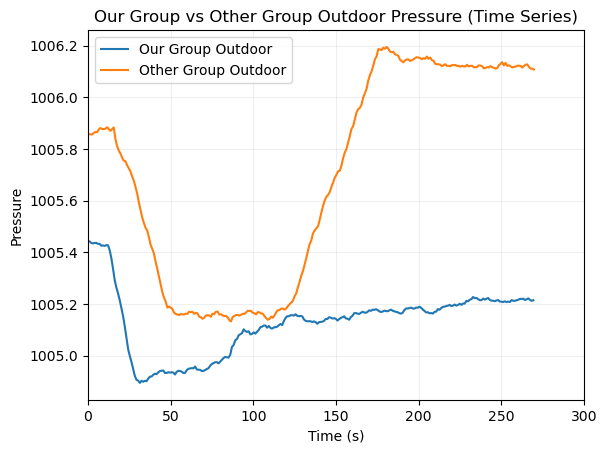

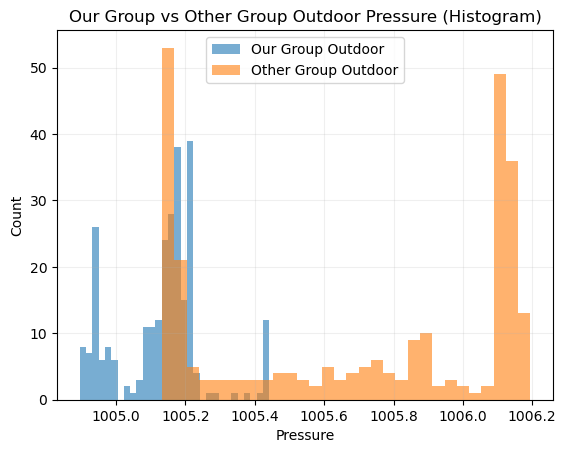

--- Outdoor Pressure ---
N Our Group Outdoor = 266, N Other Group Outdoor = 267
Mean Our Group Outdoor  = 1005.13
Mean Other Group Outdoor = 1005.69
Sigma (intrinsic) Our Group Outdoor  = 0.123058
Sigma (intrinsic) Other Group Outdoor = 0.413625
Sigma_mean Our Group Outdoor  = 0.00754518
Sigma_mean Other Group Outdoor = 0.0253134
|Δmean| = 0.564559
Combined sigma_mean (for Δ) = 0.026414
Separation (|Δmean| / σΔmean) = 21.3735 σ
Statistically different at > 3σ


In [17]:
# Outdoor: Pressure
compare_one_variable(
    df_a=our_outdoor,
    df_b=other_outdoor,
    col_a="Pressure",
    col_b="Pressure",
    label_a="Our Group Outdoor",
    label_b="Other Group Outdoor",
    env_label="Outdoor",
    var_label="Pressure",
)


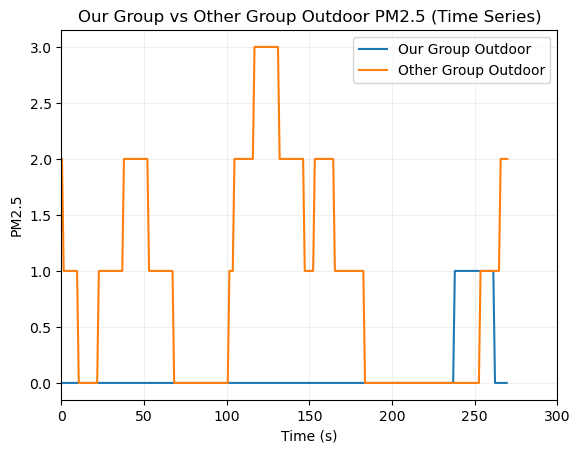

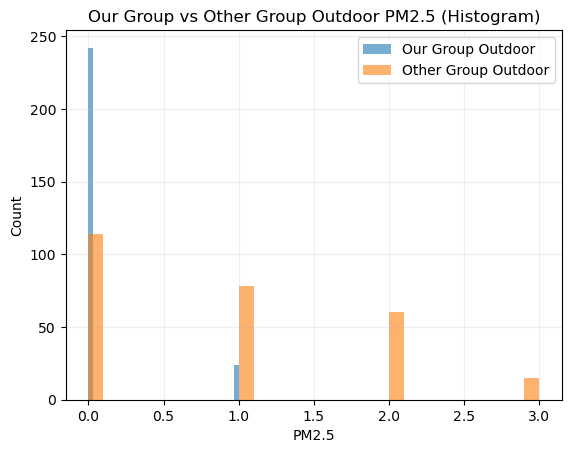

--- Outdoor PM2.5 ---
N Our Group Outdoor = 266, N Other Group Outdoor = 267
Mean Our Group Outdoor  = 0.0902256
Mean Other Group Outdoor = 0.910112
Sigma (intrinsic) Our Group Outdoor  = 0.287045
Sigma (intrinsic) Other Group Outdoor = 0.933589
Sigma_mean Our Group Outdoor  = 0.0175998
Sigma_mean Other Group Outdoor = 0.0571347
|Δmean| = 0.819887
Combined sigma_mean (for Δ) = 0.0597841
Separation (|Δmean| / σΔmean) = 13.7141 σ
Statistically different at > 3σ


In [18]:
# Outdoor: PM2.5
compare_one_variable(
    df_a=our_outdoor,
    df_b=other_outdoor,
    col_a="PM25_Env",
    col_b="2.5",
    label_a="Our Group Outdoor",
    label_b="Other Group Outdoor",
    env_label="Outdoor",
    var_label="PM2.5",
)


### Analysis

Indoor:
- Overall, the indoor measurements of the other group tend to be much more distributed than those of our group. Also, our indoor data tends to be much more Gaussian than the outdoor data due to this, so it is likely that more indoor data for the other group needs to be collected for the central limit theorem to apply. The only exceptions to this are the other group's pressure measurements, which appear to follow Gaussian statsistics somewhat more than other outdoor variables, and PM_25 air quality measurements as the number of counts was zero for all indoor measurements of both groups. All measurements collected by our group vs the other group were found to be statistically different to greater than 99.7% confidence, that is the means of each measurement were separated by at least 3 mean standard deviations, except for PM_25 air quality measurements for the same reason outlined above.

Outdoor:
- Overall, the outdoor measurements of both groups tend to be much more distributed than the indoor measurements. Also, the only outdoor measurement that appears to follow Gaussian statistics for is pressure for our group, so it is likely that more outdoor data for all other variables needs to be collected for both groups forn the central limit theorem to apply. All measurements collected by our group vs the other group were found to be statistically different to greater than 99.7% confidence, that is the means of each measurement were separated by at least 3 mean standard deviations.

Sensor Comparison:
- It can be seen from the fact that the other group's measurements are much more distributed that the weather sensor of our group was more precise.
- Comparing accuracy, there is a notable offset in the means of each measurement collected by both groups. It is hard to say which sensor is more accurate than the other without knowing the true temperature, pressure, etc values, but assuming that room temperature is 72F = 22C, it can be seen that the weather sensor of our group which records an mean indoor mean temperature of 23.3C compared to 17.6C by the other group is more accurate. The offset between measurements is significantly less notable for humidity and pressure measurements, meaning that the weather sensors of both groups have similar accuracies for these variables.
- Comparing PM_25 air quality data, it can be seen that the other groups air quality has a higher sensitivity as they recorded much higher PM-25 counts for outdoor measurements.

- Note that the other group's data file did not include any gas measurements, so it has been excluded from the analysis